# **1. A Gaussian integral**

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)


## Answer

We can write down our functio to incorporate a gaussian:

$$  f(x) = x^3 e^{\frac{-x^2}{2\sigma^2}} = \frac{\sigma \sqrt{2\pi}}{\sigma\sqrt{2\pi}}x^3e^{\frac{-x^2}{2\sigma^2}}   $$

The integral would become:

$$  \int_0^\infty p(x)f(x)dx    $$
$$  p(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{\frac{-x^2}{2\sigma^2}} \hspace{1cm} f(x) = \sigma \sqrt{2\pi}x^3    $$

And can be approximated as:

$$  \frac{1}{N}\sum_{i=1}^{N}f(\{x_i\}) $$



In [164]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [165]:
sigma = 4
xi = stats.norm(0, sigma).rvs(1000000)
xi = xi[xi >= 0]

def f(x):
    """
    Function to calculate the value of f(x) = x^3

    Parameters:
        x (float or array-like): Input value(s)
    
    Returns:
        float or array-like: f(x) = x^3
    """
    return x**3
# Calculate f(xi) for each element in xi
Integral = (1/2) * sigma * np.sqrt(2*np.pi) * np.mean(f(xi)) #Factor 1/2 is added to account for the fact that we are only integrating from 0 to infinity, which is half of the total area under the normal distribution curve.
print("The value of the numerical integral is:", Integral, "While the analytical one is", 2 * sigma**4)
print("Are the values close?", np.isclose(Integral / (2*sigma**4), 1, atol=0.01))


The value of the numerical integral is: 511.4743644834164 While the analytical one is 512
Are the values close? True


As N increaes, the mean approches the true gaussian mean and the variance also. Hence, the monte carlo simulated integral gets closer to the analytical true value.

# **2. Kicking horses**

A famous early application of low-number statistics was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898.

He studied the distribution of 122 men kicked to death by horses among 10 Prussian army corps within 20 years (so a total number of corps of 200). He recorded the number of corps with a given number of deaths:
[Data](https://www-jstor-org.proxy-ub.rug.nl/stable/1403193?seq=1)
| Number of deaths per corps per year | Number of corps |
| --- | --- |
| 0 | 109 |
| 1 | 65 |
| 2 | 22 |
| 3 | 3 |
| 4 | 1 |

- Plot the resulting probability distribution. Careful with the normalization
- How does it look like? Again try to fit it by hand.

(Hint: think about sample mean and sample variance)


In [166]:
#Create the data
Data = np.empty(0)
for i in range(109):
    Data = np.append(Data, 0)
for i in range(65):
    Data = np.append(Data, 1)
for i in range(22):
    Data = np.append(Data, 2)
for i in range(3):
    Data = np.append(Data, 3)
for i in range(1):
    Data = np.append(Data, 4)
Data = np.random.permutation(Data)
mu = np.mean(Data)
distribution = np.bincount(Data.astype(int)) / len(Data)

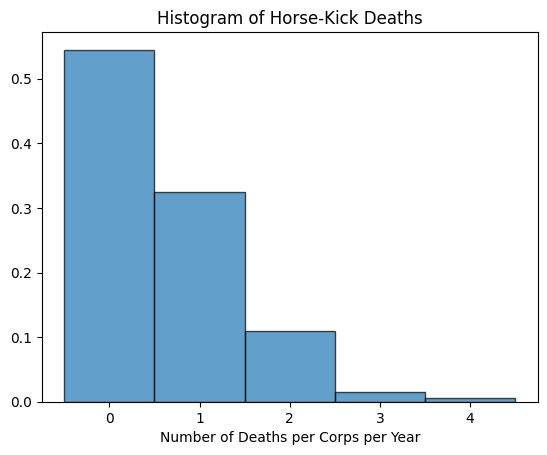

In [167]:
#Plotting the data
plt.hist(Data, bins=np.arange(-0.5, 5.5, 1), density=True, edgecolor='black', alpha=0.7, label='Data')
plt.xlabel('Number of Deaths per Corps per Year')
plt.title('Histogram of Horse-Kick Deaths')
plt.xticks(np.arange(0, 5, 1))
plt.show()

This probability distribution is a classic case of a Poisson Distribution

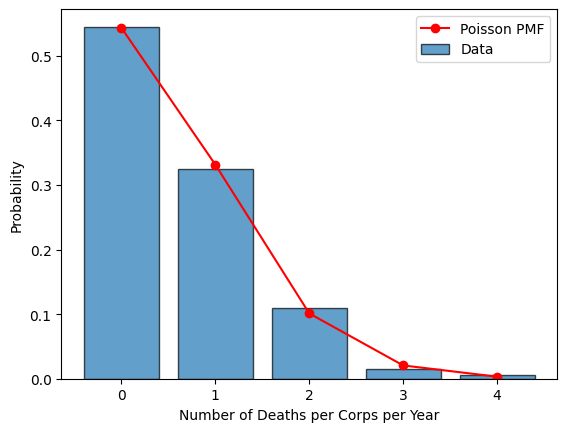

In [168]:
poisson_dist = stats.poisson(mu)
x = np.arange(0, 5)
plt.bar(x, distribution, alpha=0.7, label='Data', edgecolor='black')
plt.plot(x, poisson_dist.pmf(x), 'ro-', label='Poisson PMF')
plt.xlabel('Number of Deaths per Corps per Year')
plt.ylabel('Probability')
plt.legend()
plt.show()